In [1]:
"""
v4_parallel_send.py
--------------------
A LangGraph pipeline that reads a free-format MT599 SWIFT settlement message
(which may contain one or more distinct instructions -- cancellations,
creations, amendments -- mixed together in plain text) and produces ONE
structured JSON output: a list of instructions, each tagged with its type
and validated against type-specific required fields.

This file is self-contained: schema, LLM setup, prompt, graph nodes, graph
build, visualization, and a test invocation. It does not depend on any
other file.

Pipeline, in plain English:

    1. EXTRACT       -- one LLM call reads the whole message and returns
                        EVERY instruction found in it, as structured JSON
                        matching a fixed Pydantic schema. Two DIFFERENT
                        failure-handling mechanisms are used together here:
                          - RetryPolicy (LangGraph-native): automatically
                            retries the WHOLE node, with backoff, for
                            TRANSIENT failures (network blips, timeouts).
                          - Manual fallback (hand-written): immediately
                            switches to a different extraction STRATEGY
                            for DETERMINISTIC failures (a schema/grammar
                            problem that would fail again identically if
                            simply retried).

    2. DISPATCH (Send) -- NEW in this version. Instead of looping through
                        the extracted instructions one at a time, a single
                        routing function returns a LIST of Send(...)
                        objects -- one per instruction. LangGraph runs all
                        of them in PARALLEL, in one "superstep."

    3. VALIDATE       -- each parallel branch checks, in plain Python (no
                        LLM call), whether the fields required for that
                        instruction's type are present. Each branch writes
                        its single result into a state field that uses a
                        REDUCER to merge all the parallel writes into one
                        list, instead of overwriting each other.

    4. HUMAN REVIEW   -- once every parallel branch has finished (LangGraph
                        waits for all of them before moving on), any
                        instruction still missing a required field is
                        collected here. Since the data was never in the
                        message text, re-asking the LLM can't help -- so
                        the graph PAUSES (via interrupt()) and hands the
                        gaps to a human, who may know the value from
                        somewhere the message never covered. If nothing is
                        missing, this step is skipped entirely.

    5. FINALIZE       -- all processed instructions (reflecting any
                        human-supplied corrections) are assembled into a
                        single JSON object: {"instructions": [...]}.
"""

import os
import json
import uuid
import operator
from enum import Enum
from typing import Optional, List, Dict, Annotated, TypedDict

from pydantic import BaseModel, Field, ValidationError
from langchain_together import ChatTogether
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command, Send, RetryPolicy


# ---------------------------------------------------------------------------
# 1. STRUCTURED OUTPUT SCHEMA
# ---------------------------------------------------------------------------

class InstructionType(str, Enum):
    """
    The ONE field used for type-specific validation logic below, so it's
    constrained to a fixed set of values instead of free text.
    """
    cancel = "cancel"
    create = "create"
    amend = "amend"
    unidentified = "unidentified"  # used when no operation could be found


class Instruction(BaseModel):
    """
    One settlement instruction extracted from the message.

    Design decision: every field except `type` is a plain Optional[str].
    We deliberately do NOT try to cast qty to int or settlementDate to a
    date object here. Reasons:
      1. MT599 is free text -- dates/numbers can appear in inconsistent
         formats, and asking a small LLM to also normalize formats increases
         the chance of it silently getting the normalization wrong.
      2. The receiving settlement system already owns format validation
         against its own static/reference data.
      3. Keeping types uniform (all str) keeps the schema and the prompt
         simple -- which matters when the LLM is a small instruct model.
    """
    type: InstructionType = Field(
        description="The operation identified from the message text."
    )
    clientRef: Optional[str] = Field(
        default=None, description="Client reference for this instruction."
    )
    scRef: Optional[str] = Field(
        default=None, description="SC (settlement/system) reference, if present."
    )
    isin: Optional[str] = Field(
        default=None, description="ISIN of the security, if present."
    )
    qty: Optional[str] = Field(
        default=None, description="Quantity, captured exactly as written."
    )
    settlementDate: Optional[str] = Field(
        default=None, description="Settlement date, captured exactly as written."
    )
    sfkAccount: Optional[str] = Field(
        default=None, description="SFK account number, if present."
    )
    pset: Optional[str] = Field(
        default=None, description="Place of settlement, if present."
    )
    party: Optional[str] = Field(
        default=None, description="Party details, if present."
    )
    cpty: Optional[str] = Field(
        default=None, description="Counterparty details, if present."
    )
    remarks: Optional[str] = Field(
        default=None,
        description=(
            "Free-text notes explaining any problem with this instruction. "
            "Populated when type is 'unidentified', or when a required "
            "field is missing (e.g. 'Missing required fields: isin, qty'). "
            "Cleared automatically if a human later supplies the missing "
            "value during review."
        ),
    )


class ExtractionResult(BaseModel):
    """
    Top-level shape returned by this pipeline. ALWAYS a list, even for a
    single instruction, and ALWAYS non-empty -- downstream consumers never
    need to handle "no instructions" as a different shape from "one" or
    "many" instructions.
    """
    instructions: List[Instruction] = Field(
        description=(
            "One or more instructions found in the message. If nothing "
            "could be identified, return exactly one instruction with "
            "type='unidentified' and an explanation in remarks."
        )
    )


C:\Users\Pandiyan\anaconda3\envs\langchain\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dotenv import load_dotenv
load_dotenv(".env")
# ---------------------------------------------------------------------------
# 2. LLM SETUP (Together AI via LangChain)
# ---------------------------------------------------------------------------

TOGETHER_MODEL = "Qwen/Qwen2.5-7B-Instruct-Turbo"

llm = ChatTogether(
    model=TOGETHER_MODEL,
    temperature=0,  # deterministic extraction -- repeatable JSON, not creative text
    together_api_key=os.getenv("TOGETHER_API_KEY"),
)

# Preferred mode: ask Together to constrain the model's output to our
# schema. Fast when it works.
structured_llm_json_schema = llm.with_structured_output(ExtractionResult, method="json_schema")


def _manual_json_extract(prompt: str) -> ExtractionResult:
    """
    DETERMINISTIC-FAILURE fallback: prompt the raw `llm` for plain JSON text
    (no schema sent to the provider at all), then parse and validate the
    response ourselves. Used when json_schema mode fails for a reason that
    would fail again identically on a plain retry -- e.g. Together AI's
    grammar compiler rejecting a schema shape it doesn't support well.
    """
    manual_prompt = (
        prompt
        + "\n\nRespond with ONLY a single valid JSON object -- no markdown "
        "code fences, no explanation, no text before or after the JSON. "
        'The JSON must have this exact top-level shape: {"instructions": [...]}, '
        "where each item in the list has the fields described above."
    )
    raw_text = llm.invoke(manual_prompt).content.strip()

    if raw_text.startswith("```"):
        raw_text = raw_text.strip("`")
        if raw_text.lower().startswith("json"):
            raw_text = raw_text[4:]
        raw_text = raw_text.strip()

    data = json.loads(raw_text)                    # may raise json.JSONDecodeError
    return ExtractionResult.model_validate(data)    # may raise pydantic.ValidationError


In [3]:

# ---------------------------------------------------------------------------
# 3. PROMPT
# ---------------------------------------------------------------------------

EXTRACTION_PROMPT = """You are parsing a free-format MT599 SWIFT message used in trade settlement.

The message may contain ONE OR MORE distinct instructions (cancellation, creation, amendment),
mixed together in free text, in any order.

For EACH instruction you find, extract:
- type: cancel, create, amend, or unidentified
- clientRef, scRef, isin, qty, settlementDate, sfkAccount, pset, party, cpty
- remarks: only used to explain when type is "unidentified"

Rules:
1. Capture every field exactly as written in the message. Do NOT reformat dates,
   numbers, or reference codes.
2. If a field is not mentioned for an instruction, leave it null. Do not guess.
3. If you cannot identify ANY operation in the entire message, return exactly ONE
   instruction with type="unidentified" and a short explanation in remarks.
4. Return every instruction you find -- do not drop or merge separate instructions.

Message:
\"\"\"{message}\"\"\"
"""


In [4]:

# ---------------------------------------------------------------------------
# 4. REQUIRED FIELDS PER TYPE
#    Shared lookup table used by both the parallel validation branches
#    (section 8) and the human_review node (section 9), so the business
#    rule for "what counts as complete" is defined in exactly one place.
# ---------------------------------------------------------------------------

REQUIRED_FIELDS_BY_TYPE: Dict[InstructionType, List[str]] = {
    InstructionType.cancel: ["clientRef"],
    InstructionType.create: ["clientRef", "isin", "qty", "sfkAccount"],
    InstructionType.amend: ["clientRef"],
    InstructionType.unidentified: [],
}


def _missing_fields(instruction: Instruction, required: List[str]) -> List[str]:
    """
    Given a list of field names that MUST be present for this instruction's
    type, return the subset that are actually missing (None or blank).
    """
    missing = []
    for field_name in required:
        value = getattr(instruction, field_name)
        if value is None or str(value).strip() == "":
            missing.append(field_name)
    return missing


def _append_missing_note(instruction: Instruction, missing: List[str]) -> Instruction:
    """
    Write a "Missing required fields: x, y" note into `remarks`, appending
    rather than overwriting so an existing remark is never erased.
    """
    if not missing:
        return instruction
    note = f"Missing required fields: {', '.join(missing)}"
    instruction.remarks = f"{instruction.remarks}; {note}" if instruction.remarks else note
    return instruction



In [5]:

# ---------------------------------------------------------------------------
# 5. GRAPH STATE
#    processed_instructions uses a REDUCER (Annotated[..., operator.add])
#    because MULTIPLE PARALLEL BRANCHES (one per Send, see section 8) will
#    each write to this field at the same time. Without a reducer,
#    LangGraph would have no defined way to combine those simultaneous
#    writes -- with operator.add, each branch's single-item list gets
#    CONCATENATED into one combined list automatically.
# ---------------------------------------------------------------------------

class SettlementState(TypedDict):
    raw_message: str  # input: the MT599 free text

    all_instructions: List[Instruction]
    # The full list returned by extraction. Read by the dispatch function
    # (section 8) to decide how many parallel branches to create -- never
    # written to after extraction.

    processed_instructions: Annotated[List[Instruction], operator.add]
    # Starts empty. Each parallel validation branch returns exactly ONE
    # single-item list here; the operator.add reducer concatenates all of
    # them together once every branch has finished. This REPLACES the
    # current_index + sequential-loop bookkeeping used in earlier versions
    # of this pipeline -- there's no "current instruction" pointer anymore,
    # because every instruction is handled in its own parallel branch.

    result: Optional[ExtractionResult]  # final output
    error: Optional[str]                # extraction-level error, if any


class InstructionValidationState(TypedDict):
    """
    The state schema for the PARALLEL VALIDATION BRANCH only -- deliberately
    separate from SettlementState. Each Send(...) call (section 8) hands
    exactly this shape to the validate_instruction node: just the ONE
    instruction that branch is responsible for. The branch has no visibility
    into the rest of SettlementState (all_instructions, raw_message, etc.)
    -- it only sees what was explicitly passed in the Send.
    """
    instruction_to_validate: Instruction



In [6]:

# ---------------------------------------------------------------------------
# 6. NODE: extract_instructions
#    One LLM call reads the entire message and returns every instruction it
#    can find. Failure handling is deliberately split into TWO mechanisms
#    with two different jobs:
#
#      - RetryPolicy (attached to this node at graph-build time, see
#        section 10) automatically retries the WHOLE node call, with
#        backoff, ONLY for exceptions that look transient (the default
#        retry_on covers connection errors, timeouts, 5xx responses).
#        Retrying an IDENTICAL call makes sense here -- a network blip may
#        simply not happen the second time.
#
#      - The manual fallback INSIDE this function handles DETERMINISTIC
#        failures instead: a Pydantic validation error, or Together AI's
#        "failed to compile grammar" error. These would fail again
#        identically on a plain retry, so instead of retrying the same
#        call, we immediately switch to a different extraction STRATEGY
#        (manual prompt-and-parse, bypassing the schema entirely) within
#        this same call -- no reliance on RetryPolicy for this class of
#        failure.
# ---------------------------------------------------------------------------

def extract_instructions(state: SettlementState) -> SettlementState:
    message = state["raw_message"]
    prompt = EXTRACTION_PROMPT.format(message=message)

    try:
        result = structured_llm_json_schema.invoke(prompt)
    except (ValidationError, json.JSONDecodeError) as deterministic_error:
        # Pydantic couldn't validate what came back -- retrying the exact
        # same call would very likely fail the same way. Switch strategy
        # immediately instead.
        result = _fallback_after_deterministic_failure(prompt, deterministic_error)
    except Exception as e:
        # Heuristic classification: if the error message itself points to
        # a schema/grammar problem, treat it as deterministic (same
        # reasoning as above). NOTE: in a real production system you would
        # check the provider SDK's actual exception types here instead of
        # inspecting error text -- this is a simplification for teaching
        # purposes, since langchain_together does not expose a distinct
        # exception class for "grammar compile failed" versus a generic
        # API error.
        if "grammar" in str(e).lower() or "schema" in str(e).lower():
            result = _fallback_after_deterministic_failure(prompt, e)
        else:
            # Looks transient (network/timeout/unknown provider error) --
            # re-raise so RetryPolicy (see section 10) retries this WHOLE
            # node automatically, with backoff.
            raise

    state["all_instructions"] = result.instructions
    state["error"] = None
    return state


def _fallback_after_deterministic_failure(prompt: str, original_error: Exception) -> ExtractionResult:
    """
    Called only after a DETERMINISTIC failure on the preferred json_schema
    path. Tries the manual prompt-and-parse strategy once; if THAT also
    fails, gives up gracefully with a single 'unidentified' placeholder
    instruction, so the rest of the graph always has a valid, non-empty
    list to fan out over (see section 8) -- it never has to special-case
    "extraction failed entirely" as a different shape.
    """
    try:
        return _manual_json_extract(prompt)
    except Exception as fallback_error:
        return ExtractionResult(
            instructions=[
                Instruction(
                    type=InstructionType.unidentified,
                    remarks=(
                        f"Extraction failed. Preferred mode error: {original_error}. "
                        f"Fallback mode error: {fallback_error}."
                    ),
                )
            ]
        )



In [7]:

# ---------------------------------------------------------------------------
# 7. NODE: validate_instruction (the Send target)
#    Runs ONCE PER INSTRUCTION, in parallel, as dispatched by
#    dispatch_to_validation() below. Receives ONLY an
#    InstructionValidationState -- a single instruction, nothing else.
#    Checks required fields with plain Python (no LLM call) and returns a
#    single-item list, which the operator.add reducer on SettlementState
#    merges together with every other branch's result.
# ---------------------------------------------------------------------------

def validate_instruction(state: InstructionValidationState) -> dict:
    instruction = state["instruction_to_validate"]
    required = REQUIRED_FIELDS_BY_TYPE.get(instruction.type, [])
    missing = _missing_fields(instruction, required)
    instruction = _append_missing_note(instruction, missing)

    # Returning a PARTIAL state update -- LangGraph merges this single-item
    # list into SettlementState.processed_instructions using the
    # operator.add reducer declared in section 5. We do NOT need to (and
    # cannot) update all_instructions or any other SettlementState field
    # from here -- this branch only knows about its own instruction.
    return {"processed_instructions": [instruction]}



In [8]:

# ---------------------------------------------------------------------------
# 8. DISPATCH FUNCTION (the Send fan-out)
#    Instead of returning a single string key (like a normal conditional
#    edge), this function returns a LIST of Send(...) objects -- one per
#    instruction found during extraction. LangGraph interprets this as:
#    "run validate_instruction once per Send, all in parallel, in one
#    superstep, and don't move on until every one of them has finished."
# ---------------------------------------------------------------------------

def dispatch_to_validation(state: SettlementState) -> List[Send]:
    return [
        Send("validate_instruction", {"instruction_to_validate": instruction})
        for instruction in state["all_instructions"]
    ]


In [9]:

# ---------------------------------------------------------------------------
# 9. NODE: human_review
#    Runs once, AFTER every parallel validation branch has finished (this
#    is automatic -- LangGraph waits for the whole Send superstep to
#    complete before the fixed edge to human_review fires). Looks for
#    instructions still missing required fields and, ONLY if there are any,
#    pauses the graph with interrupt() so a human can supply values that
#    were never in the original message text in the first place.
#
#    IMPORTANT (LangGraph behaviour): when a graph resumes after an
#    interrupt, the node RE-RUNS FROM THE TOP -- everything before the
#    interrupt() call executes again. That's safe here because the
#    "find what's missing" logic is pure computation with no side effects.
# ---------------------------------------------------------------------------

def human_review(state: SettlementState) -> SettlementState:
    incomplete = []
    for index, instruction in enumerate(state["processed_instructions"]):
        required = REQUIRED_FIELDS_BY_TYPE.get(instruction.type, [])
        missing = _missing_fields(instruction, required)
        if missing:
            incomplete.append({
                "index": index,
                "clientRef": instruction.clientRef,
                "type": instruction.type.value,
                "missing_fields": missing,
            })

    if not incomplete:
        return state  # nothing to review -- skip the pause entirely

    human_updates = interrupt({
        "message": (
            "The following instructions are missing required fields that "
            "were NOT present in the original MT599 message text. Supply "
            "values only if known from another source (e.g. static account "
            "reference data, a call to the client) -- otherwise leave "
            "unresolved."
        ),
        "items": incomplete,
    })
    # Expected shape once supplied via Command(resume=...):
    #   { "0": {"sfkAccount": "5678"} }

    if human_updates:
        for index_str, field_updates in human_updates.items():
            instruction = state["processed_instructions"][int(index_str)]
            for field_name, value in field_updates.items():
                setattr(instruction, field_name, value)

    for item in incomplete:
        instruction = state["processed_instructions"][item["index"]]
        required = REQUIRED_FIELDS_BY_TYPE.get(instruction.type, [])
        still_missing = _missing_fields(instruction, required)
        instruction.remarks = (
            f"Missing required fields: {', '.join(still_missing)}"
            if still_missing else None
        )

    return state



In [10]:

# ---------------------------------------------------------------------------
# 10. NODE: finalize
# ---------------------------------------------------------------------------

def finalize(state: SettlementState) -> SettlementState:
    state["result"] = ExtractionResult(instructions=state["processed_instructions"])
    return state


In [11]:

# ---------------------------------------------------------------------------
# 11. BUILD THE GRAPH
#     Structure, in plain English:
#       extract_instructions --(dispatch_to_validation, returns Send list)--> validate_instruction (N parallel branches)
#       validate_instruction -> human_review   (fixed edge -- LangGraph waits for ALL branches first)
#       human_review -> finalize
#
#     RetryPolicy is attached ONLY to extract_instructions -- it's the only
#     node that calls an external API and can genuinely fail transiently.
#     validate_instruction/human_review/finalize are pure Python -- nothing
#     for a retry policy to meaningfully protect against there.
# ---------------------------------------------------------------------------

builder = StateGraph(SettlementState)

builder.add_node(
    "extract_instructions",
    extract_instructions,
    retry_policy=RetryPolicy(
        max_attempts=3,       # first call + up to 2 automatic retries
        initial_interval=0.5,  # wait 0.5s before the first retry
        backoff_factor=2.0,    # then 1s, then 2s, etc. if it keeps failing
        # retry_on left at its default: transient categories (connection
        # errors, timeouts, 5xx) -- NOT ValueError/TypeError-style bugs.
    ),
)
builder.add_node("validate_instruction", validate_instruction)
builder.add_node("human_review", human_review)
builder.add_node("finalize", finalize)

builder.set_entry_point("extract_instructions")

# Send-based fan-out: dispatch_to_validation returns a LIST of Send objects
# instead of a single string key. The third argument here just lists every
# node this dispatch function is allowed to target (LangGraph uses it for
# graph-shape validation/visualization) -- it is NOT a string->node mapping
# like a normal add_conditional_edges call.
builder.add_conditional_edges("extract_instructions", dispatch_to_validation, ["validate_instruction"])

# Fixed edge: LangGraph automatically waits for EVERY validate_instruction
# branch to finish (the whole Send superstep) before this edge fires.
builder.add_edge("validate_instruction", "human_review")
builder.add_edge("human_review", "finalize")
builder.set_finish_point("finalize")

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)



In [12]:

# ---------------------------------------------------------------------------
# 12. VISUALIZE THE GRAPH
# ---------------------------------------------------------------------------

def visualize_graph(compiled_graph, output_path: str = "graph_v4.png") -> None:
    try:
        png_bytes = compiled_graph.get_graph().draw_mermaid_png()
    except Exception as e:
        print(f"Graph visualization failed (mermaid/graphviz dependency issue?): {e}")
        return

    try:
        from IPython.display import Image, display
        from IPython import get_ipython
        if get_ipython() is not None:
            display(Image(png_bytes))
            return
    except ImportError:
        pass

    with open(output_path, "wb") as f:
        f.write(png_bytes)
    print(f"Graph diagram saved to: {output_path}")


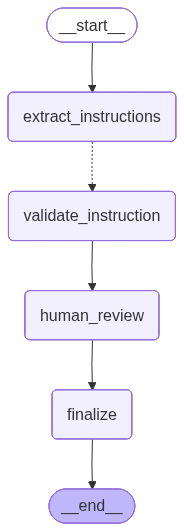


--- Graph paused for human review ---
The following instructions are missing required fields that were NOT present in the original MT599 message text. Supply values only if known from another source (e.g. static account reference data, a call to the client) -- otherwise leave unresolved.

Instruction #1 (type=create, clientRef=QWERTY) is missing: sfkAccount


  Enter value for 'sfkAccount' (or press Enter to skip):  6788


Deserializing unregistered type __main__.InstructionType from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'InstructionType')]
Deserializing unregistered type __main__.Instruction from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Instruction')]



--- Final result ---
{
  "instructions": [
    {
      "type": "cancel",
      "clientRef": "XYZABC",
      "scRef": null,
      "isin": null,
      "qty": null,
      "settlementDate": null,
      "sfkAccount": null,
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    },
    {
      "type": "create",
      "clientRef": "QWERTY",
      "scRef": null,
      "isin": "DFGHISIN",
      "qty": "100",
      "settlementDate": null,
      "sfkAccount": "6788",
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    },
    {
      "type": "amend",
      "clientRef": "AMEND001",
      "scRef": null,
      "isin": null,
      "qty": null,
      "settlementDate": "5th July",
      "sfkAccount": null,
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    },
    {
      "type": "cancel",
      "clientRef": "XYZABC",
      "scRef": null,
      "isin": null,
      "qty": null,
      "settlementDate": nu

In [13]:

# ---------------------------------------------------------------------------
# 13. QUICK TEST -- demonstrates parallel fan-out + a full pause/resume cycle
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    visualize_graph(graph)

    # Same three-instruction message as earlier versions, still missing
    # SFK Account on the create instruction, to exercise BOTH the parallel
    # validation AND the human_review pause in the same run.
    sample_message = (
        "Please cancel the trade has client reference XYZABC, "
        "Also create a new trade with client reference QWERTY, "
        "it should have the ISIN DFGHISIN, Qty=100. "
        "Also amend trade with client reference AMEND001, change settlement date to 5th July."
    )

    config = {"configurable": {"thread_id": str(uuid.uuid4())}}

    initial_state = {
        "raw_message": sample_message,
        "all_instructions": [],
        "processed_instructions": [],
        "result": None,
        "error": None,
    }

    first_pass = graph.invoke(initial_state, config)

    if "__interrupt__" in first_pass:
        print("\n--- Graph paused for human review ---")
        interrupt_payload = first_pass["__interrupt__"][0].value
        print(interrupt_payload["message"])

        human_supplied_updates: dict = {}
        for item in interrupt_payload["items"]:
            index = str(item["index"])
            print(
                f"\nInstruction #{item['index']} "
                f"(type={item['type']}, clientRef={item['clientRef']}) "
                f"is missing: {', '.join(item['missing_fields'])}"
            )
            field_updates = {}
            for field_name in item["missing_fields"]:
                value = input(f"  Enter value for '{field_name}' (or press Enter to skip): ").strip()
                if value:
                    field_updates[field_name] = value
            if field_updates:
                human_supplied_updates[index] = field_updates

        final_state = graph.invoke(Command(resume=human_supplied_updates), config)
    else:
        final_state = first_pass

    print("\n--- Final result ---")
    print(json.dumps(final_state["result"].model_dump(), indent=2))


#### 